## 11 - Plotting with Pandas

### What is Pandas plotting?
Pandas has a built-in `.plot()` method that wraps Matplotlib. Instead of manually setting up `x` and `y` arrays, you call `.plot()` directly on a DataFrame and it figures out the data automatically.

### Syntax
```python
df.plot(kind='line')              # line chart
df.plot(kind='bar')               # bar chart
df.plot(kind='barh')              # horizontal bar
df.plot(kind='hist')              # histogram
df.plot(kind='box')               # box plot
df.plot(kind='scatter', x='col_a', y='col_b')   # scatter
df.plot(kind='area')              # area chart
df.plot(kind='pie', y='col')      # pie chart
```

### Shorthand methods
```python
df.plot.bar()         # same as kind='bar'
df.plot.hist()        # same as kind='hist'
df.plot.scatter(x, y) # same as kind='scatter'
```

### Key parameters
| Parameter | Effect |
|-----------|--------|
| `figsize=(w, h)` | Set figure size |
| `title='...'` | Chart title |
| `color` | Colour or list of colours |
| `legend=True` | Show legend |
| `grid=True` | Show grid |
| `rot=45` | Rotate x tick labels |
| `bins=20` | For histogram |

### Combining Pandas plot with Matplotlib
```python
df.plot(kind='bar', figsize=(9, 5))   # Pandas draws it
plt.title('My Title')                 # Matplotlib adds to it
plt.ylabel('Value')
plt.tight_layout()
plt.show()
```

> 💡 `df.plot()` always returns a Matplotlib Axes object - so you can follow it up with any `plt.` command to further customise.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
rng = np.random.default_rng(42)
n   = 50
df  = pd.DataFrame({
    'name':         [f'S{i:03d}' for i in range(1, n+1)],
    'gender':       rng.choice(['Female','Male'], n),
    'city':         rng.choice(['Delhi','Mumbai','Pune','Bangalore','Hyderabad'], n),
    'study_hours':  rng.uniform(3, 15, n).round(1),
    'maths':        rng.normal(65, 15, n).clip(0, 100).round(1),
    'science':      rng.normal(68, 13, n).clip(0, 100).round(1),
    'english':      rng.normal(72, 12, n).clip(0, 100).round(1),
    'compSci':      rng.normal(70, 14, n).clip(0, 100).round(1),
})
df['average'] = df[['maths','science','english','compSci']].mean(axis=1).round(2)

### Plot 1 : Bar chart from groupby

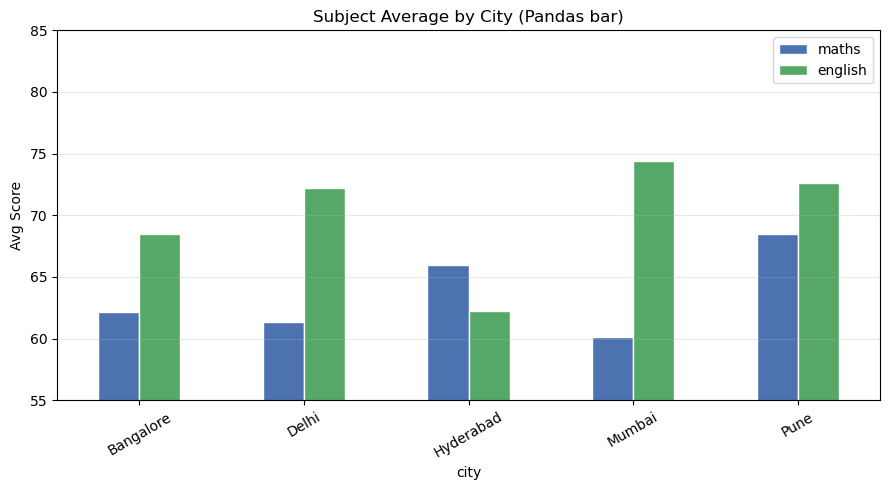

In [4]:
city_avg = df.groupby('city')[['maths','english']].mean().round(2)

city_avg.plot(kind='bar', figsize=(9, 5), color=['#4C72B0','#55A868'], edgecolor='white', rot=30)

plt.title('Subject Average by City (Pandas bar)')
plt.ylabel('Avg Score')

plt.ylim(55, 85)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Plot 2 : Histogram directly from DataFrame

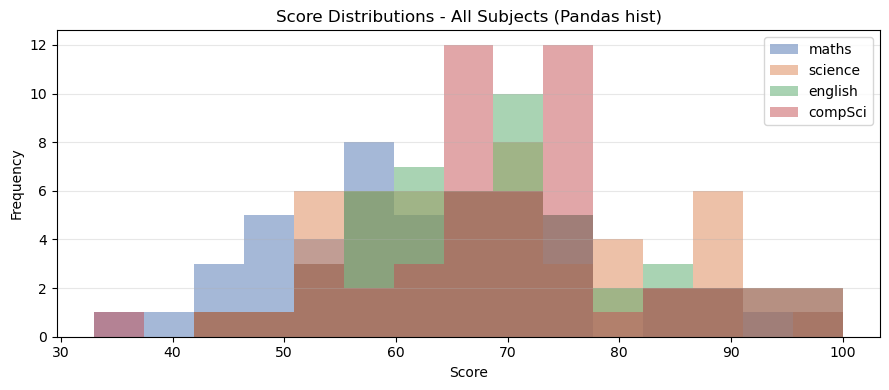

In [6]:
df[['maths','science','english','compSci']].plot(
    kind='hist', bins=15, alpha=0.5, figsize=(9, 4),
    color=['#4C72B0','#DD8452','#55A868','#C44E52'])

plt.title('Score Distributions - All Subjects (Pandas hist)')
plt.xlabel('Score')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 3 : Scatter from DataFrame

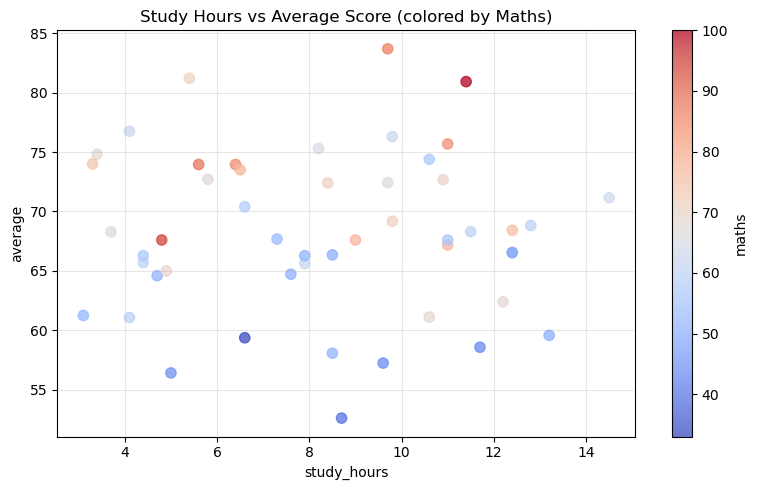

In [7]:
df.plot(kind='scatter', x='study_hours', y='average',
        c='maths', cmap='coolwarm', s=55, alpha=0.75,
        figsize=(8, 5))

plt.title('Study Hours vs Average Score (colored by Maths)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 4 : Box plot from DataFrame

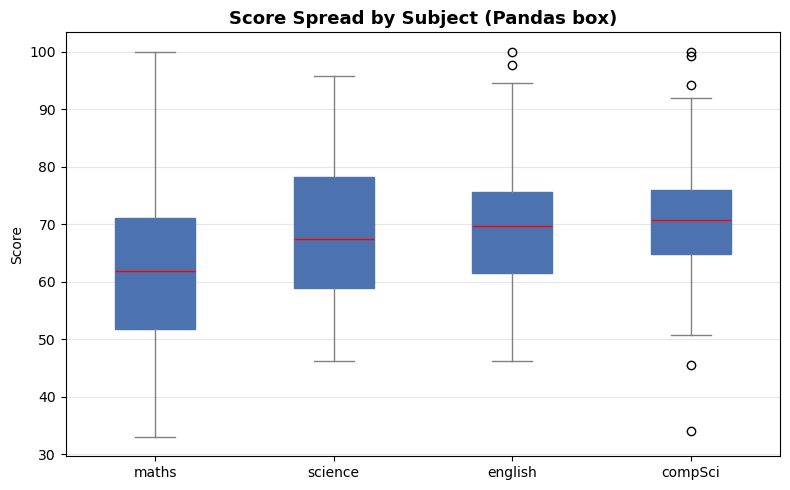

In [8]:
df[['maths','science','english','compSci']].plot(
    kind='box', figsize=(8, 5),
    color=dict(boxes='#4C72B0', medians='red', whiskers='gray', caps='gray'),
    patch_artist=True)

plt.title('Score Spread by Subject (Pandas box)', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()